<a href="https://www.kaggle.com/code/mykolarekunenko/notebook-hw-3?scriptVersionId=295453633" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Завдання:
Ознайомитись з даними та структурою даних
Створіть доповнення(transform) для тренувальних та тестових даних. посилання
Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)
Переконайтесь що у вас привильні назви класів
Створіть DataLoader для тренувальних та тестових даних
Візуалізуйте дані
Збережіть kaggle notebook для подальшої роботи

In [1]:
import torch  
from torchvision import datasets, transforms 

In [2]:
data_dir = "/kaggle/input/fruit-recognition/train/train"
# Створюємо екземпляр ImageFolder
dataset = datasets.ImageFolder(data_dir)

In [3]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [4]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

In [5]:
img, label = data_train[2000]

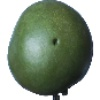

In [6]:
img

In [7]:
len(dataset), len(data_train), len(data_test)

(16854, 13484, 3370)

In [8]:
train_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.RandomRotation(180),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor()
    ] 
)

test_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.ToTensor()
    ] 
)

In [9]:
train_transform(img).shape

torch.Size([3, 64, 64])

In [10]:
test_transform(img).shape

torch.Size([3, 64, 64])

In [11]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [12]:
train_data = TransformDataset(data_train, train_transform)
test_data = TransformDataset(data_test, test_transform)

In [13]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [14]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape)

torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([42, 3, 64, 64])
torch.Size([42])


(64, 64, 3)


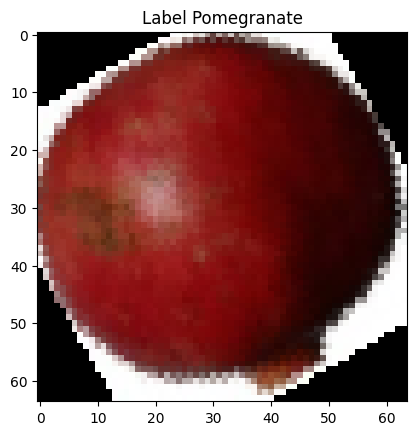

(64, 64, 3)


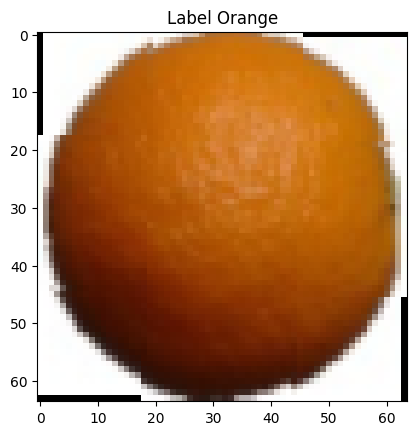

(64, 64, 3)


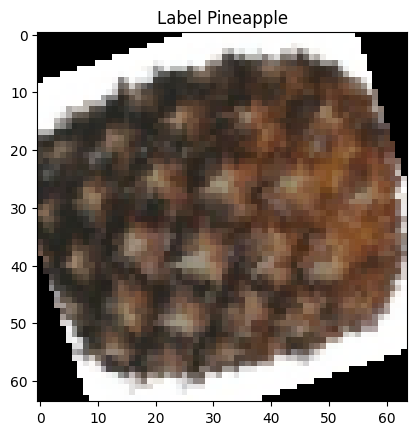

In [15]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

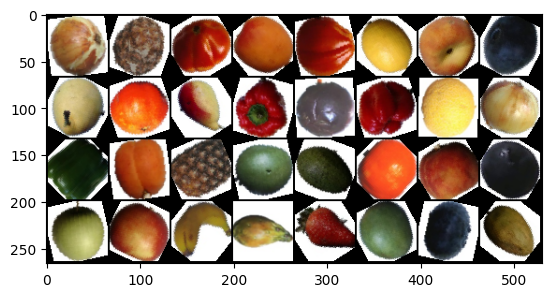

In [16]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [17]:
img, label = train_data[0]

img.shape

torch.Size([3, 64, 64])

In [18]:
3*64*64

12288

In [19]:
len(dataset.classes)

33

In [20]:
from torch import nn

#нейромережа
model = nn.Sequential(
    nn.Flatten(),   # переведе зображення 3х64х64 в нейрони 12288
    nn.Linear(12288, 128),   # на вході 12288 нейронів передає інформацію 64 нейронам
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 33)   # 33 нейрона на кожен тип фрукта
)


# підключення до процесора
device = 'cuda'
model = model.to(device)

In [21]:
img = img.unsqueeze(0).to(device)
result = model(img)
result

tensor([[ 0.0197, -0.1223, -0.0158,  0.1123,  0.0642, -0.1558, -0.0836, -0.0568,
          0.0059, -0.0495, -0.0984, -0.0386, -0.2148, -0.0909, -0.0601,  0.0443,
         -0.1131, -0.0241, -0.0078, -0.0902, -0.0107,  0.0095, -0.0609, -0.0331,
         -0.0396, -0.0134, -0.0825, -0.0395,  0.0204,  0.0470,  0.1079, -0.1366,
         -0.0433]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [29]:
#ймовірності
probs = nn.Softmax()(result)
probs

tensor([[9.5954e-01, 4.9989e-14, 9.2447e-08,  ..., 1.7546e-07, 4.2198e-07,
         1.6275e-27],
        [2.6974e-04, 3.5361e-21, 2.2301e-04,  ..., 7.5744e-08, 9.8219e-01,
         3.1032e-39],
        [6.1237e-09, 2.1400e-26, 1.0694e-03,  ..., 1.2315e-17, 9.0772e-07,
         0.0000e+00],
        ...,
        [2.1130e-07, 2.4111e-17, 1.2392e-02,  ..., 4.7685e-18, 8.5474e-09,
         1.4994e-43],
        [1.4875e-17, 1.5879e-10, 1.8487e-23,  ..., 3.5142e-05, 2.7996e-26,
         3.5257e-05],
        [1.5254e-15, 7.8572e-18, 3.9206e-25,  ..., 1.7806e-10, 4.4926e-27,
         4.0020e-14]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [23]:
label

27

**# Визначення функції втрат та оптимізатора**

In [24]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(
    model.parameters(),   # параметри нефромережі
    lr=0.001
)

loss_list = []
loss_test_list = []
for i in range(10):
    
    
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.cpu().item())

    # test data
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss_test_list.append(loss.cpu().item())

loss: 3.496004581451416
loss: 3.6196374893188477
loss: 3.538738489151001
loss: 3.361522674560547
loss: 3.382747173309326
loss: 3.2213234901428223
loss: 3.171806573867798
loss: 3.1734542846679688
loss: 3.184366226196289
loss: 2.9589760303497314
loss: 2.963200569152832
loss: 2.8318991661071777
loss: 2.8984076976776123
loss: 2.8043205738067627
loss: 2.7934799194335938
loss: 2.6324009895324707
loss: 2.6988513469696045
loss: 2.578477382659912
loss: 2.542578935623169
loss: 2.5246949195861816
loss: 2.520151138305664
loss: 2.346461772918701
loss: 2.3218798637390137
loss: 2.1607770919799805
loss: 2.235769271850586
loss: 2.1331686973571777
loss: 2.1870131492614746
loss: 2.0621562004089355
loss: 2.147170066833496
loss: 1.991910457611084
loss: 1.9346258640289307
loss: 1.9141216278076172
loss: 1.9184343814849854
loss: 1.73708176612854
loss: 1.7303061485290527
loss: 1.7920153141021729
loss: 1.7590476274490356
loss: 1.6918635368347168
loss: 1.6411433219909668
loss: 1.630683183670044
loss: 1.567678213

In [25]:
img, label = train_data[0]
img = img.unsqueeze(0)
img.shape
img = img.to(device)
prediction = model(img)

print(label)
print(nn.Softmax()(prediction))

27
tensor([[4.1872e-01, 1.4354e-17, 9.5343e-10, 4.7954e-10, 1.2171e-19, 6.8211e-20,
         9.9936e-14, 2.6238e-24, 9.0548e-05, 2.3410e-08, 9.8377e-26, 4.3619e-14,
         1.0618e-18, 2.4291e-05, 1.0231e-16, 6.7358e-27, 1.7604e-27, 6.2826e-11,
         2.7599e-12, 2.8175e-10, 1.4007e-23, 8.0524e-04, 1.7477e-13, 1.5177e-33,
         3.4375e-03, 5.8848e-11, 7.5879e-06, 5.7691e-01, 6.3526e-21, 4.7298e-17,
         1.7626e-08, 3.0696e-08, 2.0207e-31]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


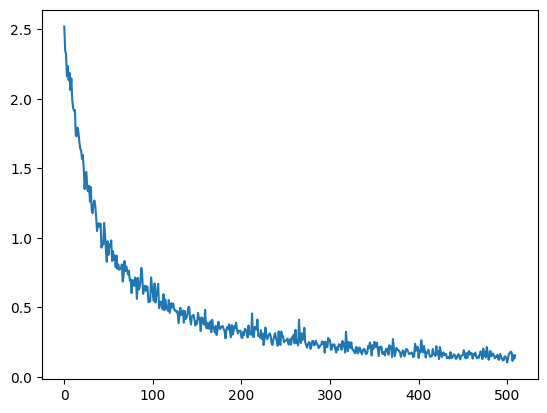

In [26]:
import matplotlib.pyplot as plt

new_list = loss_list[20:]
plt.plot(new_list)

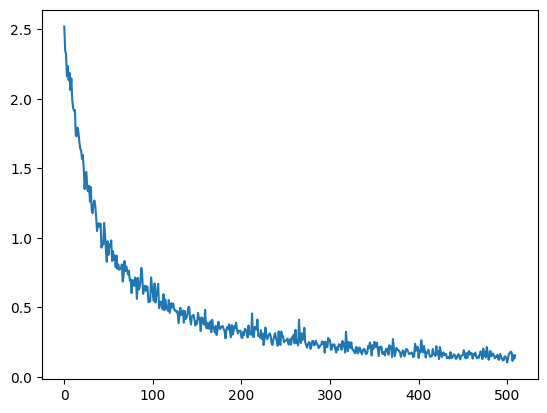

In [27]:
plt.plot(new_list)